# Etapa 1 - Analise Exploratoria de Dados (EDA)

**Datathon 7MLET - Grupo 87** | Base: *Bank Marketing* (`bank-additional-full`)

Objetivo desta EDA: transformar a base Kaggle em uma fonte **confiavel e rastreavel**
para a experimentacao adaptativa, evidenciando:

1. **Proveniencia** (fonte / versao / licenca);
2. **Estrutura** e tipos das variaveis;
3. **Distribuicao do alvo** e o desbalanceamento;
4. **Qualidade**: ausencias disfarcadas (`unknown`) e o sentinela `pdays==999`;
5. **Relacoes** features x conversao (incluindo o contexto macroeconomico);
6. **Vazamento pos-contato** (`duration`) - evidencia visual de por que e descartada.

> Reprodutivel: este notebook consome os artefatos gerados por
> `poetry run python -m src.data.prepare` (camada de dados em `src/data/`).


In [1]:
import os
import sys
from pathlib import Path

# Descobre a raiz do projeto (onde esta o pyproject.toml) e a coloca no path.
_p = Path.cwd()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
PROJECT_ROOT = _p
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.build_processed import load_processed
from src.data.load import load_raw
from src.data import quality as Q
from src.data.metadata import TARGET, PDAYS_NOT_CONTACTED

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Projeto:", PROJECT_ROOT)


Projeto: D:\5. Academia\4. Machine Learning Engineering - FIAP\projeto_5\datathon-7mlet-grupo-87


## 1. Proveniencia e carga

In [2]:
# Bruto (com 'duration', para a evidencia de vazamento) e processado (sem vazamento).
df_raw, provenance = load_raw(ensure_download=True)
df = load_processed()

print("Proveniencia:")
for k in ["dataset_name", "version", "license", "kaggle_url", "raw_sha256"]:
    print(f"  {k:12s}: {provenance[k]}")
print()
print(f"Bruto      : {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
print(f"Processado : {df.shape[0]} linhas x {df.shape[1]} colunas")


Proveniencia:
  dataset_name: Bank Marketing (bank-additional-full)
  version     : UCI 2014-02-13 (Moro et al., 2014)
  license     : CC BY 4.0 (UCI Machine Learning Repository)
  kaggle_url  : https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing
  raw_sha256  : 74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959c2c8416847e0afb4d8

Bruto      : 41188 linhas x 21 colunas
Processado : 39404 linhas x 20 colunas


## 2. Estrutura e tipos do dataset de decisao

In [3]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39404 entries, 0 to 39403
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             39404 non-null  int8    
 1   job             39404 non-null  category
 2   marital         39404 non-null  category
 3   education       39404 non-null  category
 4   default         39404 non-null  category
 5   housing         39404 non-null  category
 6   loan            39404 non-null  category
 7   contact         39404 non-null  category
 8   month           39404 non-null  category
 9   day_of_week     39404 non-null  category
 10  campaign        39404 non-null  int8    
 11  pdays           39404 non-null  int16   
 12  previous        39404 non-null  int8    
 13  poutcome        39404 non-null  category
 14  emp_var_rate    39404 non-null  float64 
 15  cons_price_idx  39404 non-null  float64 
 16  cons_conf_idx   39404 non-null  float64 
 17  euribor3m   

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


## 3. Distribuicao do alvo (`subscribed`)

Confirmamos o **forte desbalanceamento**: a classe positiva (conversao) e minoritaria.


,classe,contagem,percentual
0,0,34806,88.33
1,1,4598,11.67


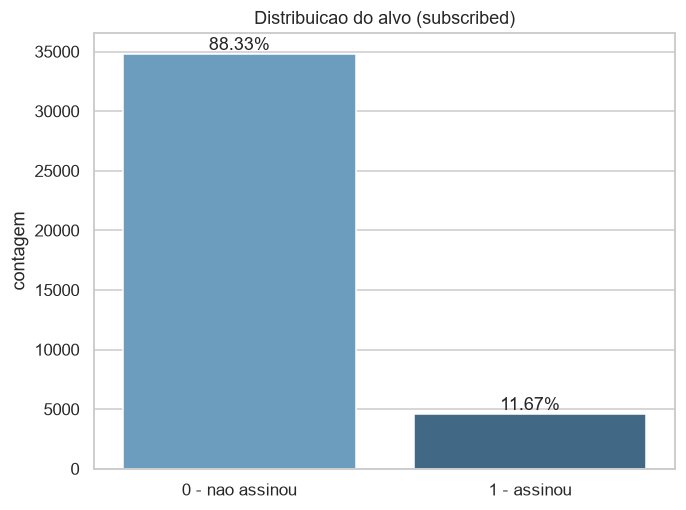

Taxa de conversao (classe positiva): 11.67%  ->  baseline 'sempre nao' acerta 88.33%


In [4]:
dist = Q.target_distribution(df)
display(dist)

ax = sns.barplot(data=dist, x="classe", y="contagem", hue="classe", palette="Blues_d", legend=False)
ax.set_xticks([0, 1]); ax.set_xticklabels(["0 - nao assinou", "1 - assinou"])
for i, row in dist.iterrows():
    ax.text(row["classe"], row["contagem"], f"{row['percentual']}%", ha="center", va="bottom")
ax.set_title("Distribuicao do alvo (subscribed)"); ax.set_xlabel(""); ax.set_ylabel("contagem")
plt.tight_layout(); plt.savefig(FIG_DIR / "target_distribution.png", bbox_inches="tight"); plt.show()

pos = float(dist.loc[dist["classe"] == 1, "percentual"].iloc[0])
print(f"Taxa de conversao (classe positiva): {pos}%  ->  baseline 'sempre nao' acerta {100-pos:.2f}%")


## 4. Qualidade - ausencias disfarcadas (`unknown`)

O CSV nao tem celulas vazias, mas varias categoricas usam `unknown`. Destaque para
`default`, com ~21% de `unknown`.


,coluna,nan,unknown,ausentes_total,ausentes_%
0,default,0,8266,8266,20.98
1,education,0,1686,1686,4.28
2,housing,0,980,980,2.49
3,loan,0,980,980,2.49
4,job,0,325,325,0.82
5,marital,0,79,79,0.20


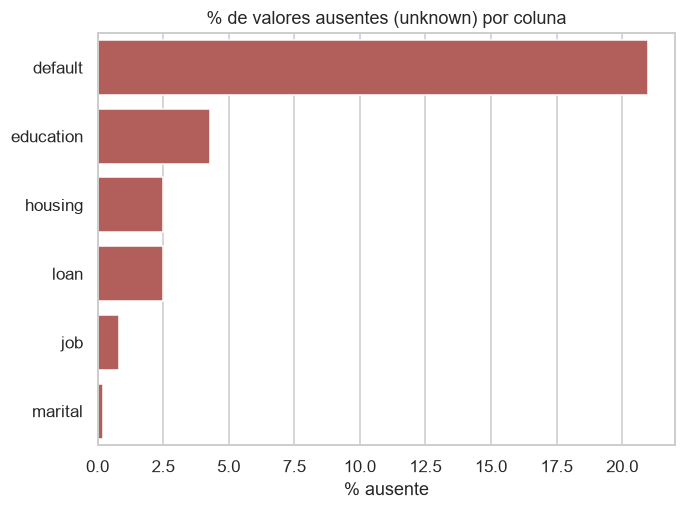

In [5]:
miss = Q.missing_report(df)
miss_nonzero = miss[miss["ausentes_total"] > 0]
display(miss_nonzero)

ax = sns.barplot(data=miss_nonzero, x="ausentes_%", y="coluna", color="#c0504d")
ax.set_title("% de valores ausentes (unknown) por coluna"); ax.set_xlabel("% ausente"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(FIG_DIR / "missing_unknown.png", bbox_inches="tight"); plt.show()


## 5. Variaveis numericas - distribuicoes

,n,media,desvio,min,q25,mediana,q75,max
age,39404.0,40.116,10.460,17.000,32.000,38.000,47.000,98.000
campaign,39404.0,2.619,2.815,1.000,1.000,2.000,3.000,56.000
pdays,39404.0,960.847,190.869,0.000,999.000,999.000,999.000,999.000
previous,39404.0,0.179,0.503,0.000,0.000,0.000,0.000,7.000
emp_var_rate,39404.0,0.064,1.577,-3.400,-1.800,1.100,1.400,1.400
cons_price_idx,39404.0,93.578,0.584,92.201,93.075,93.798,93.994,94.767
cons_conf_idx,39404.0,-40.500,4.644,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,39404.0,3.601,1.742,0.634,1.334,4.857,4.961,5.045
nr_employed,39404.0,5165.986,72.764,4963.600,5099.100,5191.000,5228.100,5228.100


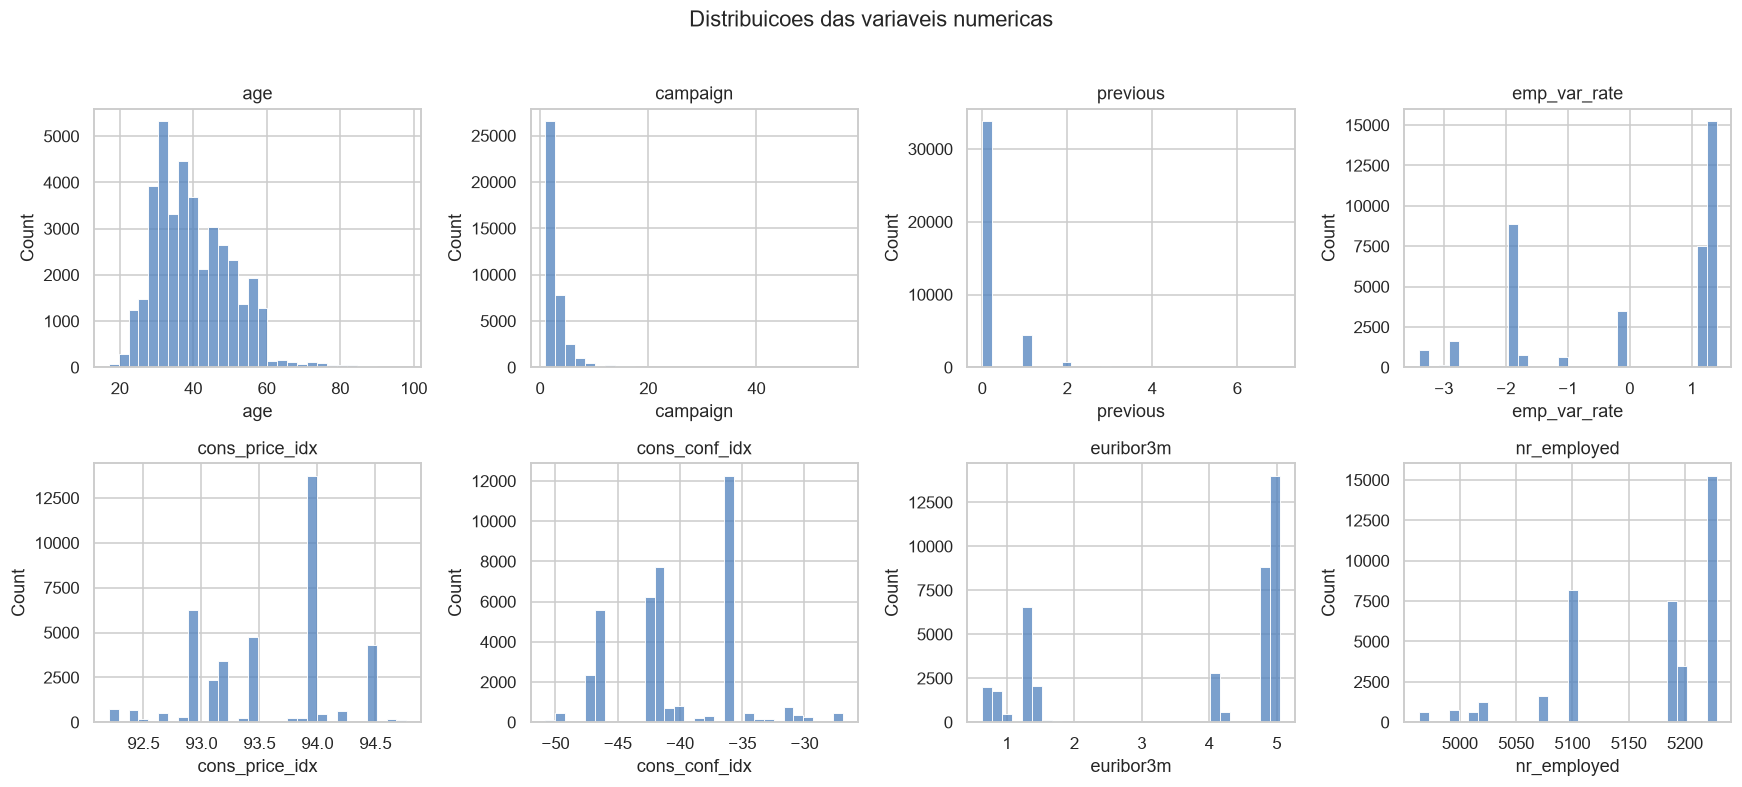

In [6]:
display(Q.numeric_summary(df))

num_cols = ["age", "campaign", "previous", "emp_var_rate",
            "cons_price_idx", "cons_conf_idx", "euribor3m", "nr_employed"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], bins=30, ax=ax, color="#4f81bd")
    ax.set_title(col)
fig.suptitle("Distribuicoes das variaveis numericas", y=1.02)
plt.tight_layout(); plt.savefig(FIG_DIR / "numeric_distributions.png", bbox_inches="tight"); plt.show()


## 6. Contexto macroeconomico x conversao

Os indicadores macro (ex.: `euribor3m`, `nr_employed`) variam com o tempo e mostram
forte relacao com a conversao - exatamente o tipo de **contexto** que um bandit
contextual deve explorar nas proximas etapas.


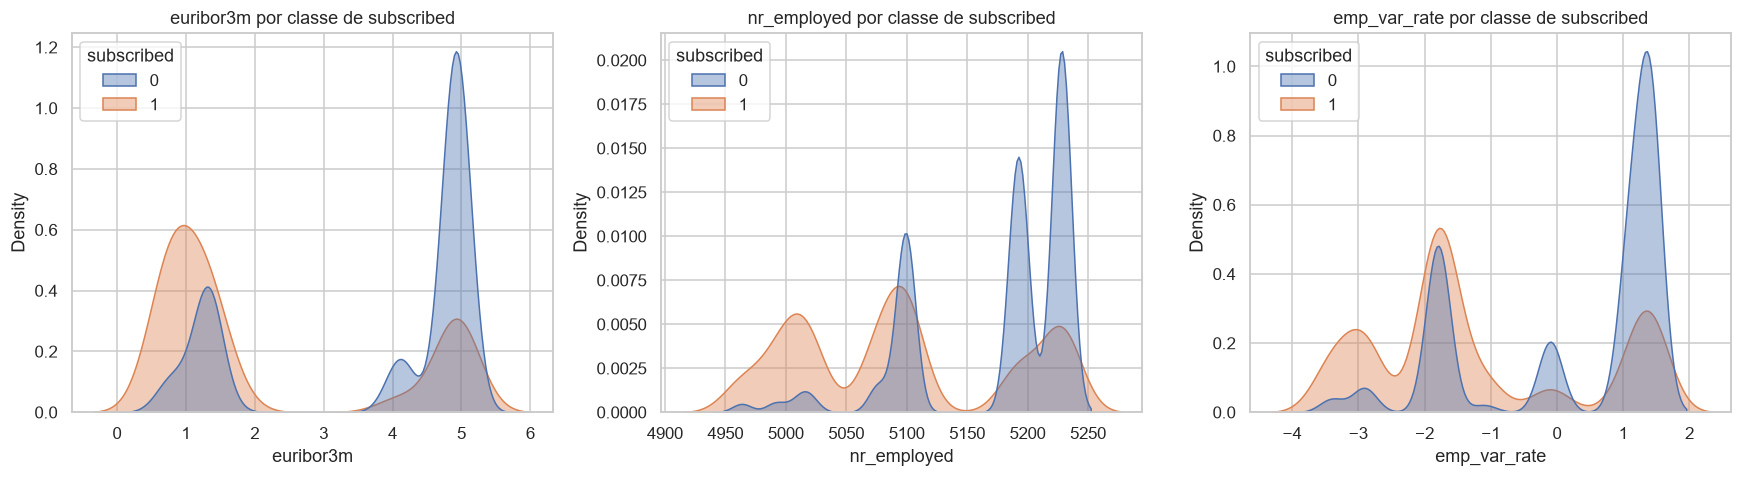

Taxa de conversao (%) por faixa etaria:
age
(16, 25]     21.46
(25, 35]     12.22
(35, 45]      8.85
(45, 55]      8.96
(55, 65]     15.58
(65, 100]    47.03
Name: subscribed, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["euribor3m", "nr_employed", "emp_var_rate"]):
    sns.kdeplot(data=df, x=col, hue=TARGET, common_norm=False, fill=True, alpha=0.4, ax=ax)
    ax.set_title(f"{col} por classe de {TARGET}")
plt.tight_layout(); plt.savefig(FIG_DIR / "macro_vs_target.png", bbox_inches="tight"); plt.show()

# Conversao por faixa etaria.
age_bins = pd.cut(df["age"], bins=[16, 25, 35, 45, 55, 65, 100])
conv_age = df.groupby(age_bins, observed=True)[TARGET].mean().mul(100).round(2)
print("Taxa de conversao (%) por faixa etaria:")
print(conv_age)


## 7. Variaveis categoricas x taxa de conversao

Taxa de conversao por categoria revela segmentos promissores (ex.: `poutcome=success`,
`contact=cellular`, estudantes/aposentados) - candidatos a contexto/segmentacao.


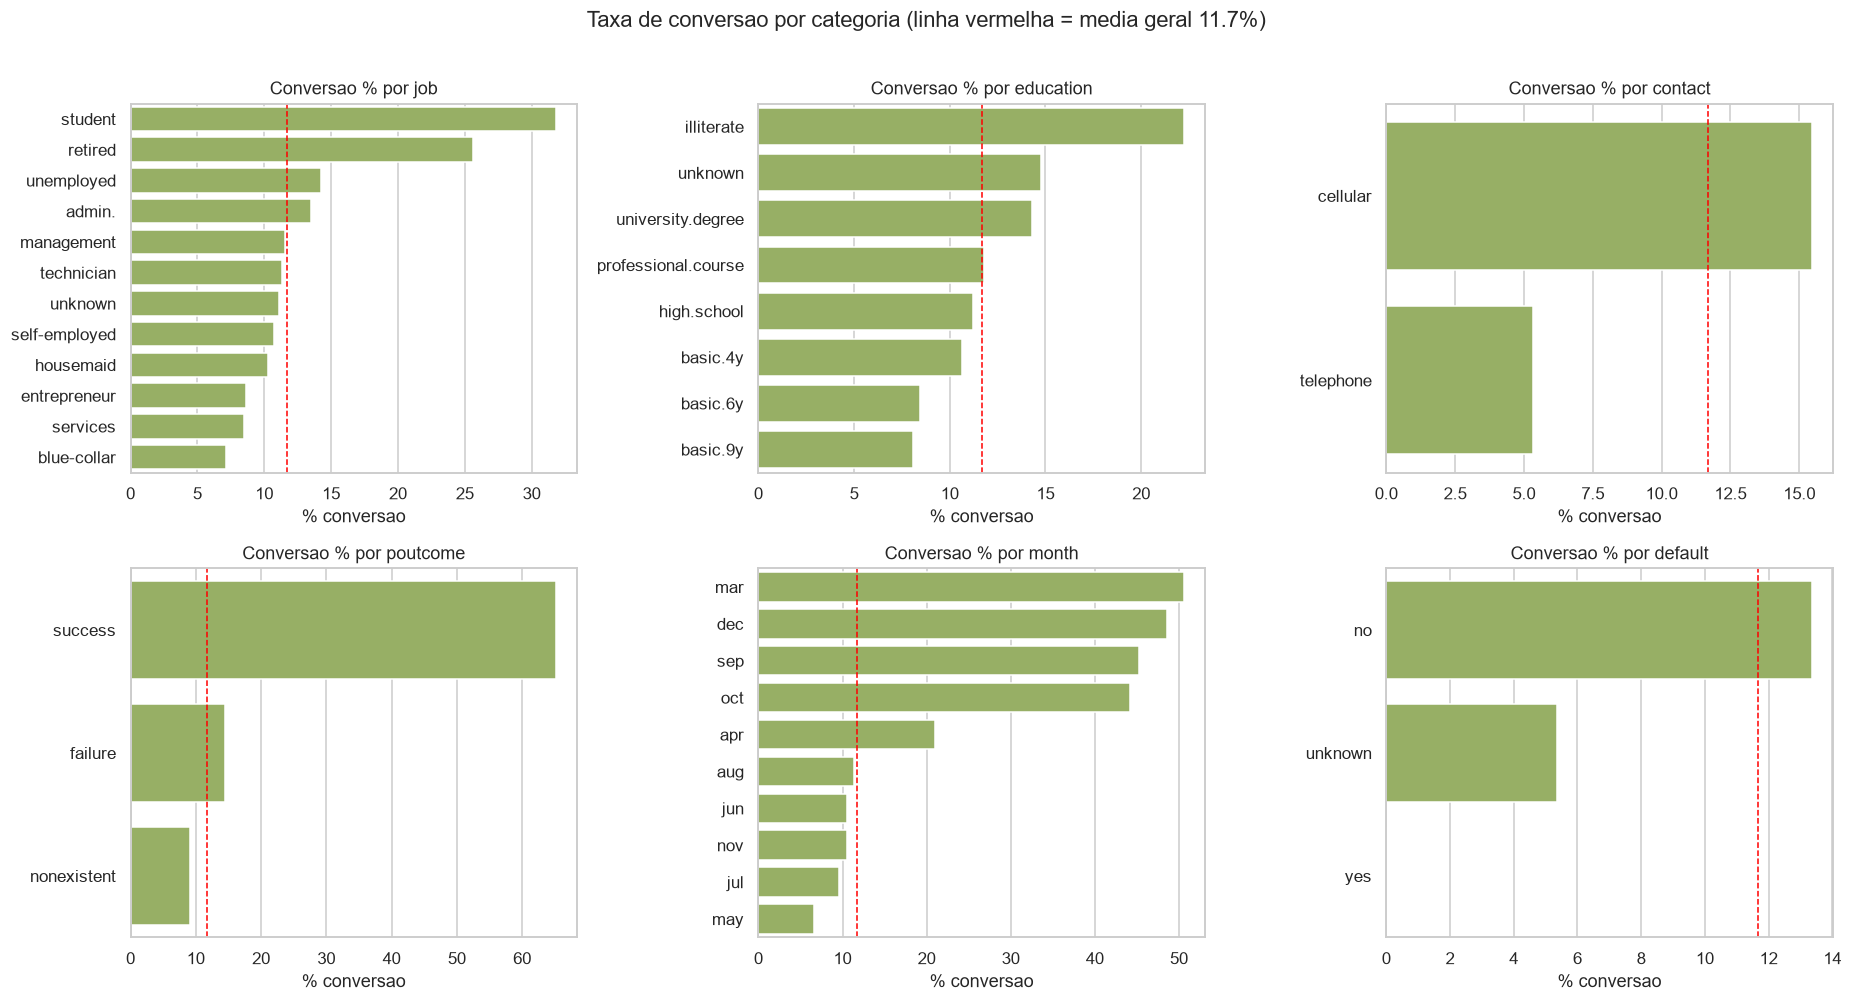

In [8]:
def conv_rate(col):
    return (df.groupby(col, observed=True)[TARGET].mean() * 100).sort_values(ascending=False)

cat_cols = ["job", "education", "contact", "poutcome", "month", "default"]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
overall = df[TARGET].mean() * 100
for ax, col in zip(axes.ravel(), cat_cols):
    cr = conv_rate(col)
    sns.barplot(x=cr.values, y=cr.index.astype(str), ax=ax, color="#9bbb59")
    ax.axvline(overall, color="red", ls="--", lw=1)
    ax.set_title(f"Conversao % por {col}"); ax.set_xlabel("% conversao"); ax.set_ylabel("")
fig.suptitle(f"Taxa de conversao por categoria (linha vermelha = media geral {overall:.1f}%)", y=1.01)
plt.tight_layout(); plt.savefig(FIG_DIR / "conversion_by_category.png", bbox_inches="tight"); plt.show()


## 8. Correlacao entre variaveis numericas

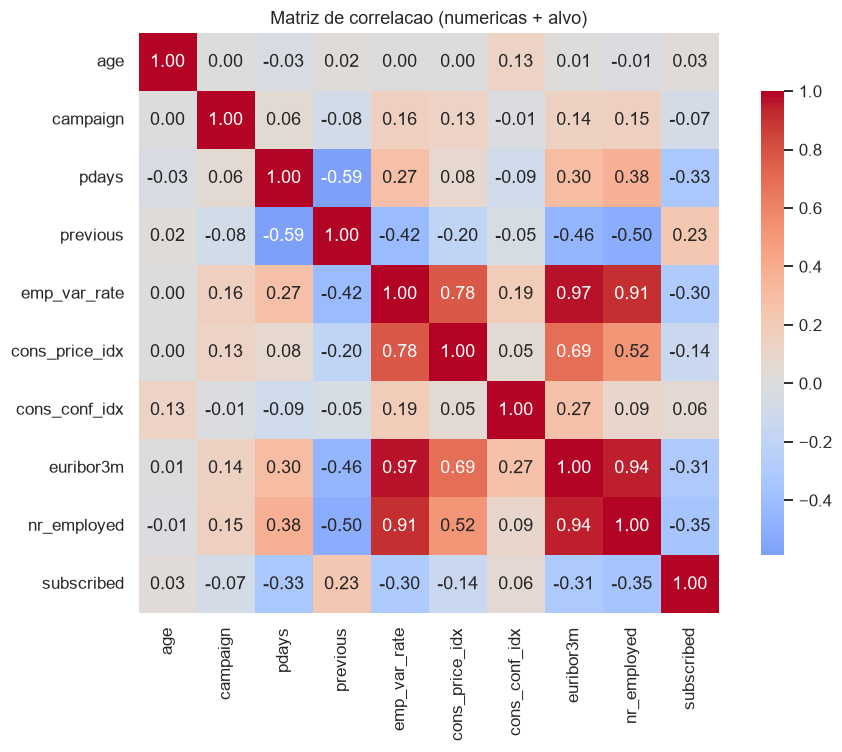

Correlacao das numericas com o alvo:
nr_employed      -0.354
pdays            -0.325
euribor3m        -0.308
emp_var_rate     -0.298
previous          0.230
cons_price_idx   -0.137
campaign         -0.072
cons_conf_idx     0.057
age               0.028
Name: subscribed, dtype: float64


In [9]:
num_all = ["age", "campaign", "pdays", "previous", "emp_var_rate",
           "cons_price_idx", "cons_conf_idx", "euribor3m", "nr_employed", TARGET]
corr = df[num_all].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .8})
plt.title("Matriz de correlacao (numericas + alvo)")
plt.tight_layout(); plt.savefig(FIG_DIR / "correlation_heatmap.png", bbox_inches="tight"); plt.show()

# Os indicadores macro sao fortemente colineares entre si (esperado).
print("Correlacao das numericas com o alvo:")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3))


## 9. Vazamento pos-contato - `duration` (por que descartamos)

`duration` so e conhecida **depois** da ligacao, quando o desfecho ja existe. Abaixo, a
evidencia quantitativa e visual: forte separacao entre classes e `duration==0 => 'no'`.


  pointbiserial_corr_duration_target: 0.4053
  n_duration_zero: 4
  share_no_when_duration_zero: 1.0
  mean_duration_subscribed: 553.2
  mean_duration_not_subscribed: 220.8


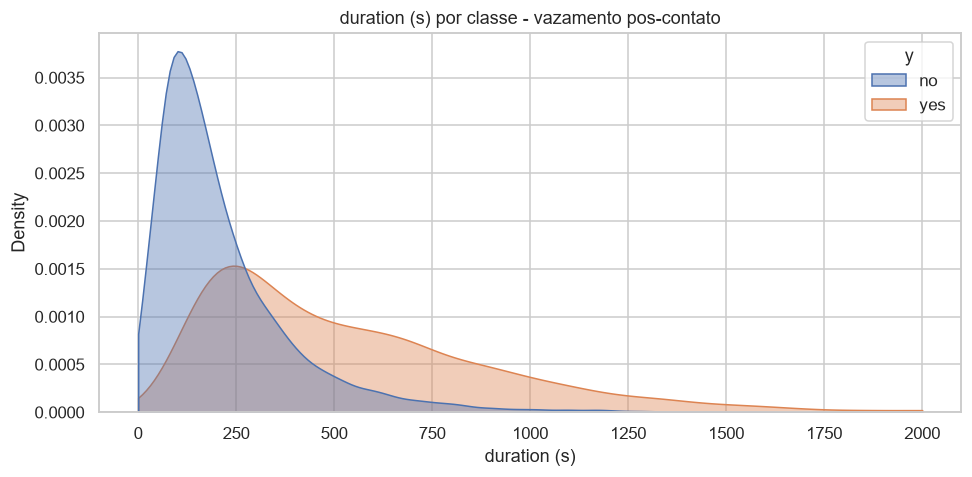


Confirmado: duration NAO esta no dataset de decisao? True


In [10]:
lk = Q.leakage_evidence(df_raw)
for k, v in lk.items():
    print(f"  {k}: {v}")

# Distribuicao de duration por classe (no bruto).
dur = df_raw[["duration", "y"]].copy()
plt.figure(figsize=(9, 4.5))
sns.kdeplot(data=dur, x="duration", hue="y", common_norm=False, fill=True, alpha=0.4, clip=(0, 2000))
plt.title("duration (s) por classe - vazamento pos-contato"); plt.xlabel("duration (s)")
plt.tight_layout(); plt.savefig(FIG_DIR / "leakage_duration.png", bbox_inches="tight"); plt.show()

print("\nConfirmado: duration NAO esta no dataset de decisao?", "duration" not in df.columns)


## 10. Sentinela `pdays == 999`

~96% dos clientes nunca foram contatados antes (`pdays==999`). E um marcador, nao um
numero continuo. Quem ja teve contato previo converte muito mais.


In [11]:
never = df["pdays"] == PDAYS_NOT_CONTACTED
print(f"pdays==999 (nunca contatado): {int(never.sum())} ({never.mean()*100:.2f}%)")
conv = df.groupby(never, observed=True)[TARGET].mean().mul(100).round(2)
conv.index = ["ja contatado antes", "nunca contatado (999)"]
print("\nTaxa de conversao (%):")
print(conv)


pdays==999 (nunca contatado): 37890 (96.16%)

Taxa de conversao (%):
ja contatado antes       63.87
nunca contatado (999)     9.58
Name: subscribed, dtype: float64


## 11. Conclusoes para as proximas etapas

- **Origem rastreavel** (fonte/versao/licenca/SHA-256) e **sem vazamento pos-contato**
  (`duration` removida) - criterio de aceite da Etapa 1 atendido.
- **Desbalanceamento forte (~11,7%)**: usar AUC-PR / recall / lift; cuidado no design de
  recompensa do bandit (recompensas esparsas).
- **Contexto util para bandit contextual**: indicadores macro (`euribor3m`, `nr_employed`,
  `emp_var_rate`), `poutcome`, `contact`, `month` e faixa etaria discriminam conversao.
- **Tratamentos pendentes (modelagem)**: `unknown` como categoria (ou imputacao), sentinela
  `pdays==999`, e colinearidade entre indicadores macro.
- **Ganchos para a Etapa 2**: as features acima formam o **contexto**; `subscribed` embasa a
  **recompensa**; as **ofertas/bracos** serao sinteticas, separadas desta base.
